# Weather Condition Classification
**Author: Eng. Noureldin Bassem Mohamed**

## 1. Introduction

A weather monitoring company runs roadside and rooftop cameras that take a new photo every few minutes,
and right now somebody has to look at each photo and tag the weather condition by hand before anything
downstream can use it, like warning a maintenance crew about ice on a bridge camera or stopping an
irrigation system while it rains. That does not scale as more cameras come online. I will build a model
that reads the photo and picks one of eleven weather conditions on its own, so a person only has to open
the shots the model is genuinely unsure about.

## 2. Import Libraries

In [1]:
import os
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
import keras

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import(
classification_report,
f1_score,
accuracy_score,
confusion_matrix,
balanced_accuracy_score
)

## 3. Loading Data

The dataset is one folder per class, no train/test split and no label column, the folder name is the label.
I download it with `kagglehub` so the notebook runs anywhere without me hardcoding a path from my machine.

In [2]:
import kagglehub

data_dir=os.path.join(kagglehub.dataset_download("jehanbhathena/weather-dataset"),"dataset")

artifacts="artifacts"

print(data_dir)
print(sorted(os.listdir(data_dir)))

C:\Users\Noureldin Bassem\.cache\kagglehub\datasets\jehanbhathena\weather-dataset\versions\3\dataset
['dew', 'fogsmog', 'frost', 'glaze', 'hail', 'lightning', 'rain', 'rainbow', 'rime', 'sandstorm', 'snow']


## 4. Variables Intialization

In [3]:
img_size=(224,224)
batch_size=32
seed=42

test_split=0.15
val_split=0.15

epochs_head=12
epochs_fine_tune=8
lr_head=1e-3
lr_fine_tune=1e-5

os.makedirs(artifacts, exist_ok=True)
keras.utils.set_random_seed(seed)

## 5. EDA

### 5.1 Building Index For Every File

In [4]:
def index_images(base_path):
    rows=[]
    for class_ in sorted(os.listdir(base_path)):
        class_dir=os.path.join(base_path,class_)

        if not os.path.isdir(class_dir):
            continue
        for image_name in sorted(os.listdir(class_dir)):
            rows.append({
                "image_path": os.path.join(class_dir,image_name),
                "class_name": class_
            })
    return pd.DataFrame(rows)


all_images_df=index_images(data_dir)

print(f"total images: {len(all_images_df)}")
all_images_df.head()

total images: 6862


,image_path,class_name
0,C:\Users\Noureldin Bassem\.cache\kagglehub\dat...,dew
1,C:\Users\Noureldin Bassem\.cache\kagglehub\dat...,dew
2,C:\Users\Noureldin Bassem\.cache\kagglehub\dat...,dew
3,C:\Users\Noureldin Bassem\.cache\kagglehub\dat...,dew
4,C:\Users\Noureldin Bassem\.cache\kagglehub\dat...,dew


### 5.2 Defining Classes

In [5]:
class_names=sorted(all_images_df["class_name"].unique())

print(f"{len(class_names)} classes: {class_names}")

11 classes: ['dew', 'fogsmog', 'frost', 'glaze', 'hail', 'lightning', 'rain', 'rainbow', 'rime', 'sandstorm', 'snow']


### 5.3 Checking Class Balance

In [6]:
counts=all_images_df["class_name"].value_counts().reindex(class_names)

class_balance_check=pd.DataFrame({
    "images": counts,
    "share": (counts/counts.sum()).round(3)
})

display(class_balance_check)

,images,share
class_name,,
dew,698,0.102
fogsmog,851,0.124
frost,475,0.069
glaze,639,0.093
hail,591,0.086
lightning,377,0.055
rain,526,0.077
rainbow,232,0.034
rime,1160,0.169


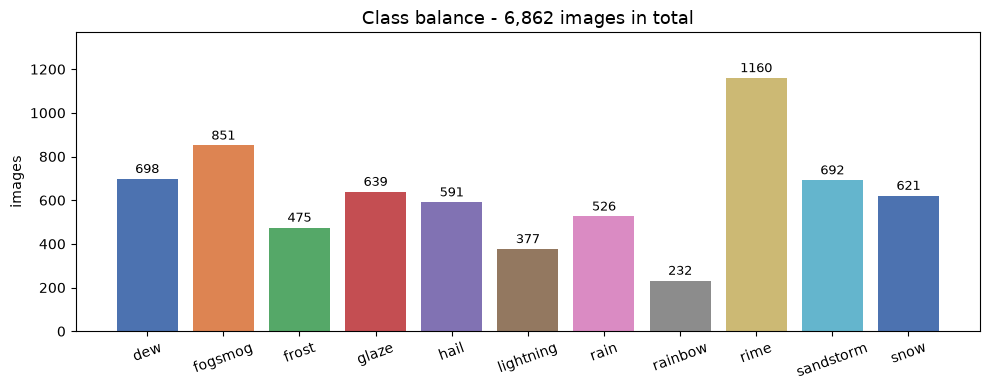

biggest class: rime (1160), smallest: rainbow (232), ratio 5.0x


In [7]:
fig, ax=plt.subplots(figsize=(10, 4))

bars=ax.bar(class_names, counts.values, color=sns.color_palette("deep", len(class_names)))
ax.bar_label(bars, padding=2, fontsize=9)
ax.set_ylim(0, counts.max()*1.18)
ax.set_ylabel("images")
ax.tick_params(axis="x", rotation=20)
ax.set_title(f"Class balance - {counts.sum():,} images in total", fontsize=13)

fig.tight_layout()
plt.show()

print(f"biggest class: {counts.idxmax()} ({counts.max()}), smallest: {counts.idxmin()} ({counts.min()}), ratio {counts.max()/counts.min():.1f}x")

The classes are not balanced. `rime` has 1160 images and `rainbow` only 232, a 5x gap, and the four
smallest classes together are smaller than `rime` on its own. Two things follow from that: accuracy on its
own will be misleading (a model can ignore `rainbow` completely and barely lose a point of accuracy), and
I should split the data in a stratified way so every class keeps its proportion in train, validation and test.

### 5.4 Looking At Images

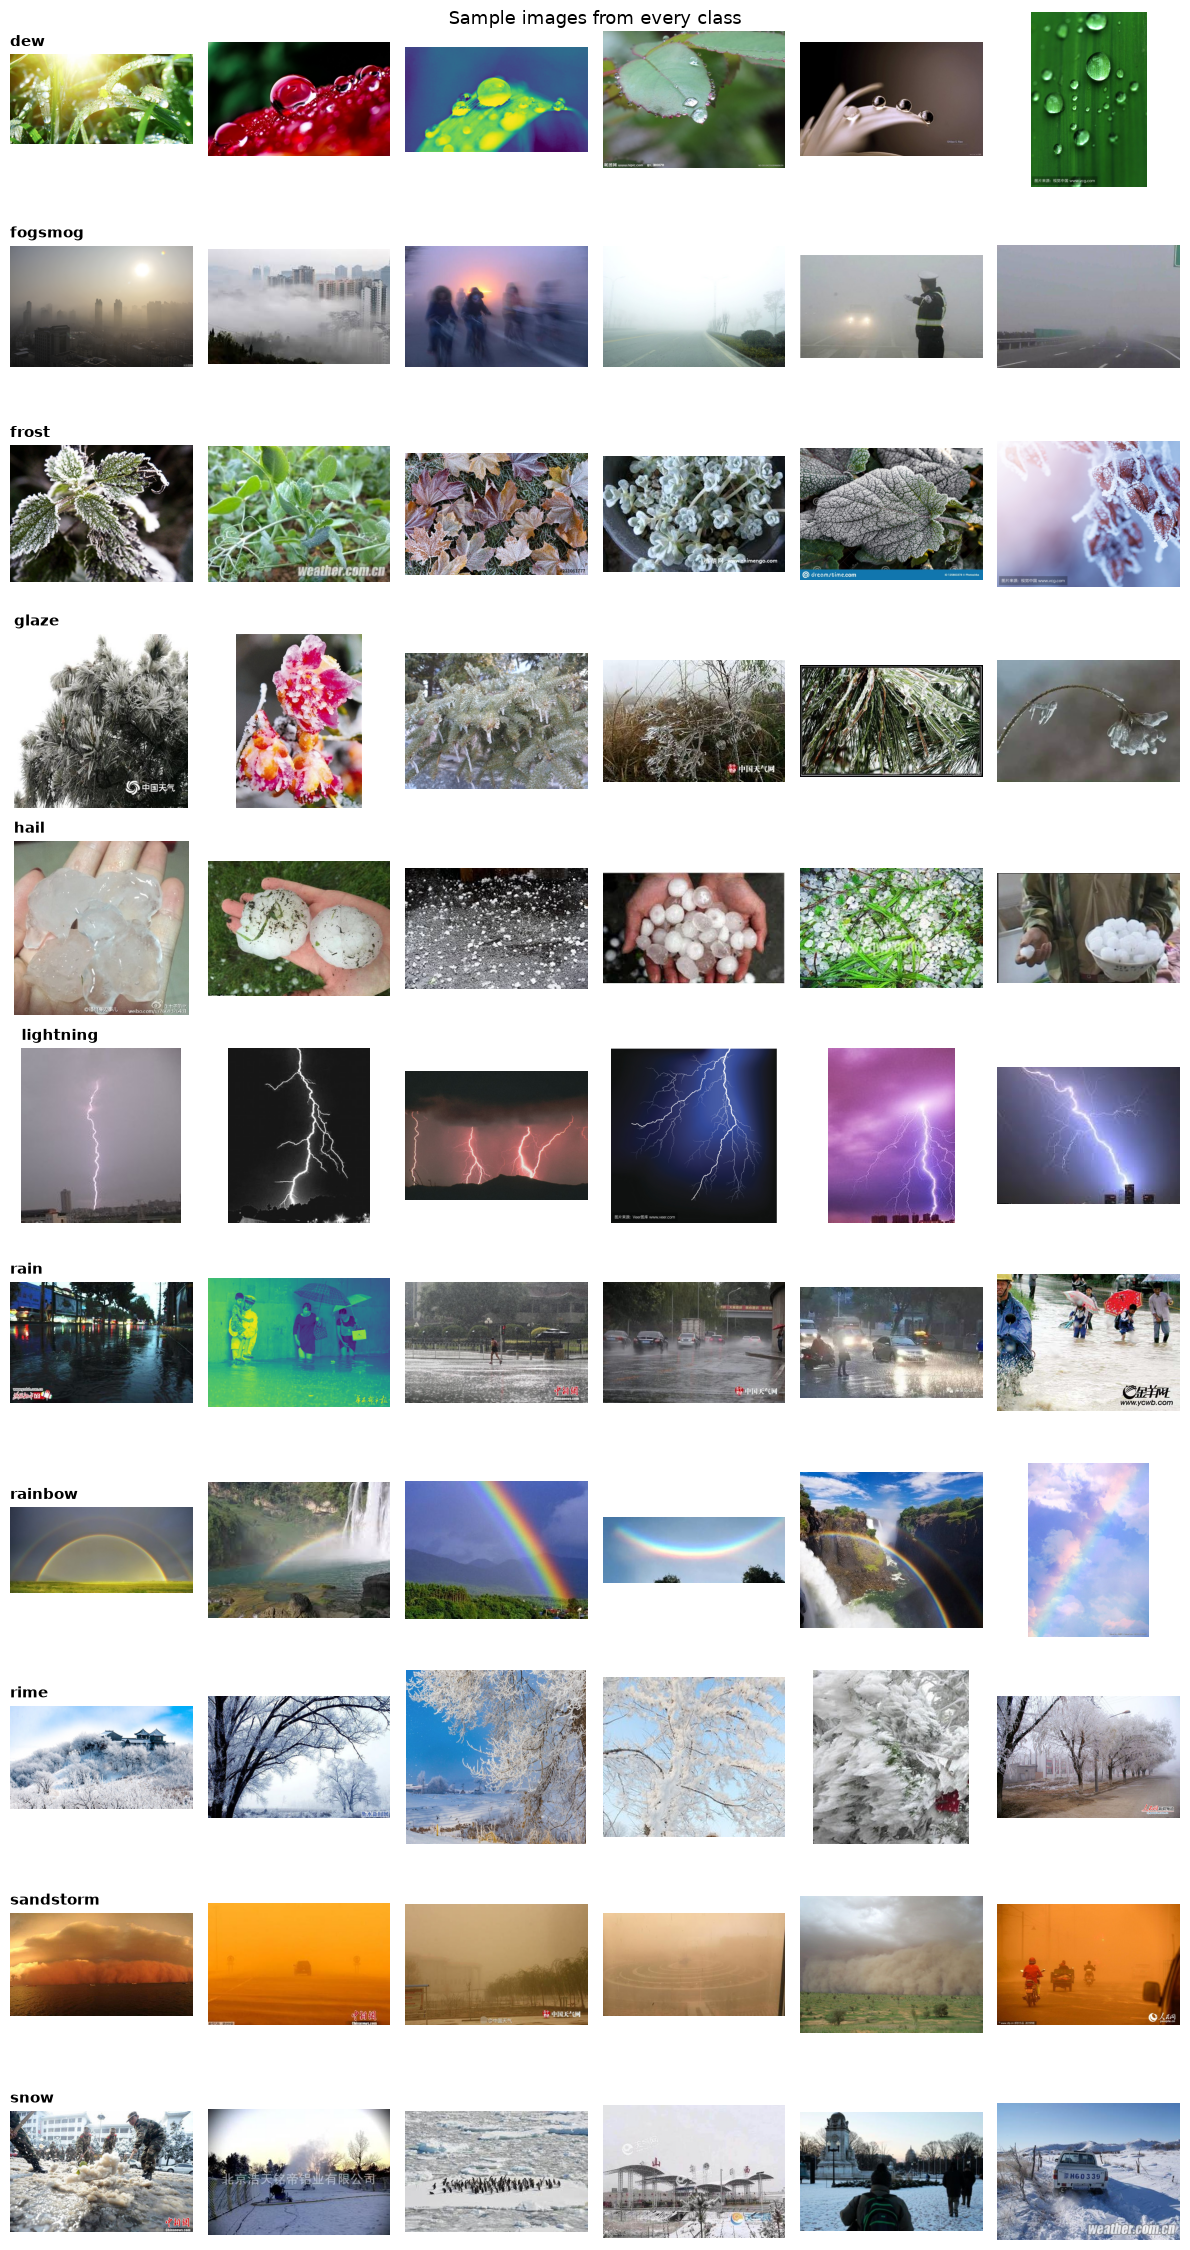

In [8]:
def show_images(df,n_per_class=6,seed=seed):
    fig,axes=plt.subplots(len(class_names),n_per_class,figsize=(n_per_class*2,2.1*len(class_names)))
    for i, label in enumerate(class_names):
        subset=df[df["class_name"]==label].sample(n=n_per_class,random_state=seed)
        for col,(_,row_data) in enumerate(subset.iterrows()):
            ax=axes[i,col]
            img=Image.open(row_data["image_path"])
            ax.imshow(img)
            ax.axis("off")
            if col==0:
                ax.set_title(label,fontsize=11,fontweight="bold",loc="left")
    fig.suptitle("Sample images from every class",fontsize=13)
    fig.tight_layout()
    plt.show()


show_images(all_images_df)

Looking at these rows next to each other:

- **frost, glaze and rime** are the ones I expect to hurt. All three are close ups of ice on a surface,
  and even by eye I cannot always say which is which. Rime is the frozen fog crust on branches, glaze is
  a clear ice layer, frost is the crystal pattern, and plenty of photos could pass for two of them.
- **dew** is also close to frost, both are macro shots of droplets or crystals on leaves and grass.
- **lightning, rainbow and sandstorm** should be the easy ones, they have a colour signature nothing else
  has, a bright bolt on a dark sky, a colour arc, an orange haze.
- **rain** is the odd one, some photos are drops on a window, some are a wet street, some are a grey sky,
  so the class itself is visually mixed.
- The photos come from different sources and are all different sizes and aspect ratios, so everything has
  to be resized to one input size anyway.

### 5.5 Image Sizes

In [9]:
sizes=[]
for path in all_images_df["image_path"].sample(400, random_state=seed):
    with Image.open(path) as img:
        sizes.append(img.size)

sizes=pd.DataFrame(sizes, columns=["width","height"])
display(sizes.describe().round(0))

print(f"unique sizes in this sample of 400: {len(sizes.drop_duplicates())}")

,width,height
count,400.0,400.0
mean,502.0,358.0
std,286.0,206.0
min,150.0,94.0
25%,400.0,251.0
50%,400.0,278.0
75%,500.0,400.0
max,3000.0,1997.0


unique sizes in this sample of 400: 245


Confirmed, there is no single native size, so resizing to the 224x224 that the backbone expects is not
throwing away a consistent resolution, it is just making a mixed pile of photos uniform.

## 6. Splitting The Data

There is no ready made train/test split here, I have to make one. I split the index twice with
`train_test_split`, stratified on the class, 70% train / 15% validation / 15% test. The test slice is put
aside and only touched in section 8, every decision before that (early stopping, how much to unfreeze, which
of the two models to keep) is made on the validation slice, so the test numbers stay honest.

In [10]:
train_df, test_df=train_test_split(
    all_images_df, test_size=test_split, stratify=all_images_df["class_name"], random_state=seed
)

train_df, val_df=train_test_split(
    train_df, test_size=val_split/(1-test_split), stratify=train_df["class_name"], random_state=seed
)

split_sizes=pd.DataFrame({
    "train": train_df["class_name"].value_counts(),
    "validation": val_df["class_name"].value_counts(),
    "test": test_df["class_name"].value_counts()
}).reindex(class_names)

display(split_sizes)
print(f"train {len(train_df)}, validation {len(val_df)}, test {len(test_df)}")

,train,validation,test
class_name,,,
dew,488,105,105
fogsmog,595,128,128
frost,333,71,71
glaze,447,96,96
hail,414,88,89
lightning,264,57,56
rain,368,79,79
rainbow,162,35,35
rime,812,174,174


train 4802, validation 1030, test 1030


Now I turn the three dataframes into `tf.data` pipelines. Each image is read, decoded, resized to 224x224
and kept as `uint8`, then `.cache()` holds the decoded images in memory so the JPEG decoding only happens
in the first epoch instead of every epoch. I do not rescale the pixels here, the backbone's own
`preprocess_input` is a layer inside the model, so the app later only has to resize a photo and hand it over.

In [11]:
def load_image(path, label):
    img=tf.io.read_file(path)
    img=tf.io.decode_image(img, channels=3, expand_animations=False)
    img=tf.image.resize(img, img_size)
    return tf.cast(img, tf.uint8), label


def make_ds(df, shuffle=False):
    labels=df["class_name"].map(class_names.index).values
    ds=tf.data.Dataset.from_tensor_slices((df["image_path"].values, labels))
    ds=ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE).cache()
    if shuffle:
        ds=ds.shuffle(1000, seed=seed)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


train_ds=make_ds(train_df, shuffle=True)
val_ds=make_ds(val_df)
test_ds=make_ds(test_df)

images, labels=next(iter(train_ds))
print(f"one batch: {images.shape} {images.dtype}, labels {labels.numpy()[:8]}")

one batch: (32, 224, 224, 3) <dtype: 'uint8'>, labels [1 1 9 7 7 9 4 4]


## 7. Building The Model

Before writing any code I had to pick a few things, so here is what I chose and why:

- **Transfer learning instead of a CNN from scratch.** 6862 photos is a small dataset, a network starting
  from random weights would spend most of its training just learning edges and textures. An ImageNet
  backbone already knows those, so I only have to teach it what separates rime from glaze.
- **MobileNetV2 as the backbone** because it is small (about 2.2M parameters in the backbone), it trains in
  a reasonable time on a CPU, and the saved model stays light enough to run on a free Streamlit server.
- **224x224 input**, the size MobileNetV2 was trained on, with its own `preprocess_input` scaling the pixels
  to the [-1, 1] range the pretrained weights expect. Using a backbone with the wrong preprocessing is a
  quiet way to lose several points of accuracy.
- **Light augmentation only**: horizontal flip, small rotation, small zoom. A snowy road is still snowy
  when mirrored, but I avoided vertical flips and colour shifts, because the sky belongs on top and colour
  is exactly the signal that separates sandstorm, rainbow and lightning.
- **Class weights** in the loss, since `rime` has five times the images of `rainbow` and I do not want the
  model to buy accuracy by ignoring the small classes.
- **Two models**, A with the backbone frozen and B with its last block fine-tuned, compared on the same
  held out test set, instead of assuming the second one is better.

In [12]:
data_augmentation=keras.Sequential(
    [
        keras.layers.RandomFlip("horizontal"),
        keras.layers.RandomRotation(0.05),
        keras.layers.RandomZoom(0.10)
    ],
    name="data_augmentation"
)

The classes are imbalanced, so I weight the loss by the inverse frequency of each class. A mistake on a
`rainbow` photo then costs the model about five times what a mistake on a `rime` photo costs, which is
what stops it from quietly giving up on the small classes.

In [13]:
weights=compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(class_names)),
    y=train_df["class_name"].map(class_names.index).values
)

class_weight={i: w for i, w in enumerate(weights)}

display(pd.Series(weights, index=class_names, name="class_weight").round(2))

dew          0.89
fogsmog      0.73
frost        1.31
glaze        0.98
hail         1.05
lightning    1.65
rain         1.19
rainbow      2.69
rime         0.54
sandstorm    0.90
snow         1.00
Name: class_weight, dtype: float64

### 7.1 Model A

Model A is the feature extraction version: the backbone is frozen and carries its ImageNet weights
unchanged, and the only thing that learns is the new eleven way classifier head on top of it.

In [14]:
def build_model(num_classes=len(class_names)):
    backbone=keras.applications.MobileNetV2(
        input_shape=img_size+ (3,),
        include_top=False,
        weights="imagenet"
    )

    backbone.trainable=False

    inputs=keras.Input(shape=img_size + (3,), name="Weather_Image")

    x=data_augmentation(inputs)
    x=keras.applications.mobilenet_v2.preprocess_input(x)
    x=backbone(x,training=False)
    x=keras.layers.GlobalAveragePooling2D(name="pooling")(x)
    x=keras.layers.Dropout(0.3, name="dropout")(x)
    outputs=keras.layers.Dense(num_classes, activation="softmax", name="predictions")(x)

    return keras.Model(inputs, outputs, name="Weather_Classifier"),backbone


model,backbone=build_model()
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_head),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "Weather_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Weather_Image (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling                         │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 11)             │        14,091 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,272,075 (8.67 MB)

 Trainable params: 14,091 (55.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [15]:
callbacks_head=[
    keras.callbacks.EarlyStopping(
        monitor="val_loss",patience=3, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",factor=0.3, patience=2, min_lr=1e-6, verbose=1
    )
]

start=time.time()

history_head=model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs_head,
    class_weight=class_weight,
    callbacks=callbacks_head,
    verbose=2
)

time_head=time.time()- start

print(f"\nStage A finished in {time_head/60:.1f} minutes over {len(history_head.epoch)} epochs")

Epoch 1/12


C:\Users\Noureldin Bassem\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


151/151 - 77s - 511ms/step - accuracy: 0.6016 - loss: 1.1271 - val_accuracy: 0.7718 - val_loss: 0.6740 - learning_rate: 0.0010


Epoch 2/12


151/151 - 83s - 548ms/step - accuracy: 0.7763 - loss: 0.5801 - val_accuracy: 0.8019 - val_loss: 0.5608 - learning_rate: 0.0010


...

Epoch 9/12


151/151 - 77s - 507ms/step - accuracy: 0.8711 - loss: 0.3322 - val_accuracy: 0.8515 - val_loss: 0.4632 - learning_rate: 3.0000e-04


Epoch 9: early stopping


Restoring model weights from the end of the best epoch: 6.



Stage A finished in 12.0 minutes over 9 epochs


In [16]:
model.save(os.path.join(artifacts, "model_a_feature_extraction.keras"))
print("saved model A")

saved model A


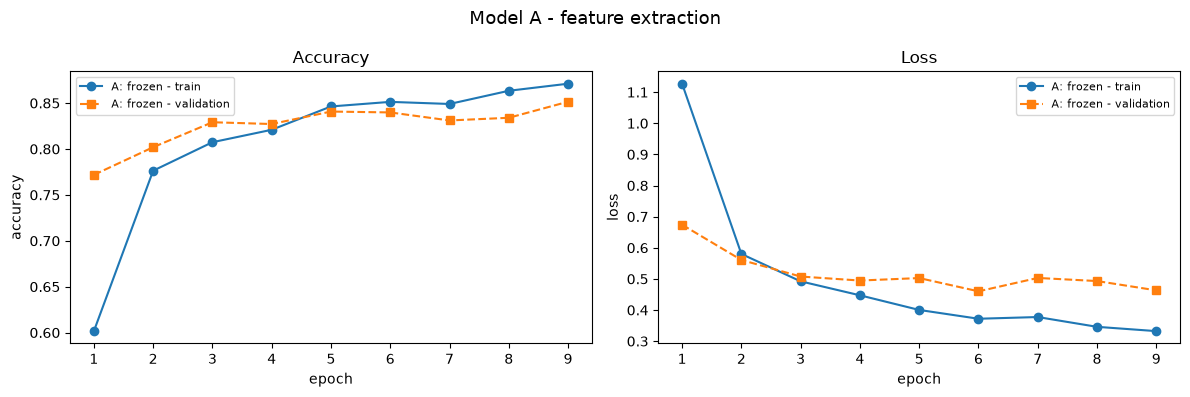

Best epoch 6: val_accuracy = 0.8398, val_loss = 0.4601


In [17]:
def plot_history(histories, title):
    """Plot accuracy and loss curves. `histories` is a list of (label, keras History)."""
    fig, axes=plt.subplots(1, 2, figsize=(12, 4))
    epoch_offset=0
    for i, (label, h) in enumerate(histories):
        epochs=np.arange(epoch_offset, epoch_offset + len(h.history["loss"])) + 1
        axes[0].plot(epochs, h.history["accuracy"], "o-", label=f"{label} - train")
        axes[0].plot(epochs, h.history["val_accuracy"], "s--", label=f"{label} - validation")
        axes[1].plot(epochs, h.history["loss"], "o-", label=f"{label} - train")
        axes[1].plot(epochs, h.history["val_loss"], "s--", label=f"{label} - validation")
        epoch_offset += len(h.history["loss"])
        if i < len(histories) - 1:          # mark where one stage ends and the next begins
            for ax in axes:
                ax.axvline(epoch_offset + 0.5, color="grey", ls=":", lw=1.2)

    axes[0].set(xlabel="epoch", ylabel="accuracy", title="Accuracy")
    axes[1].set(xlabel="epoch", ylabel="loss", title="Loss")
    for ax in axes:
        ax.legend(fontsize=8)
    fig.suptitle(title, fontsize=13)
    fig.tight_layout()
    plt.show()


plot_history([("A: frozen", history_head)], "Model A - feature extraction")

best=int(np.argmin(history_head.history["val_loss"]))
print(f"Best epoch {best + 1}: val_accuracy = {history_head.history['val_accuracy'][best]:.4f}, val_loss = {history_head.history['val_loss'][best]:.4f}")

### 7.2 Model B

Model A only trained the head, the backbone kept its generic ImageNet features. Ice textures are not an
ImageNet category, so now I unfreeze the last block of the backbone and let it adapt those features to
weather photos.

Three details that matter here:
- I only unfreeze from `block_13_expand` onward. The early layers are edges and textures which are already
  fine, and unfreezing everything on 4800 training photos is a fast way to overfit.
- The learning rate drops to `1e-5`, 100x smaller than stage A. With a big learning rate the first
  gradients would wreck the pretrained weights before they can be adapted.
- I keep the BatchNorm layers frozen so they keep their ImageNet running statistics, updating those on
  small batches is a well known way to make fine-tuning unstable.

In [18]:
unfreeze_from="block_13_expand"

backbone.trainable=True
layer_names=[layer.name for layer in backbone.layers]
cut=layer_names.index(unfreeze_from)

for layer in backbone.layers[:cut]:
    layer.trainable=False

frozen_bn=0
for layer in backbone.layers[cut:]:
    if isinstance(layer, keras.layers.BatchNormalization):
        layer.trainable=False
        frozen_bn+=1

print(f"Backbone layers : {len(backbone.layers)}")
print(f"Unfrozen from index {cut} ('{unfreeze_from}') -> {len(backbone.layers) - cut} layers")
print(f"BatchNorm layers held frozen inside that tail: {frozen_bn}")

Backbone layers : 154
Unfrozen from index 116 ('block_13_expand') -> 38 layers
BatchNorm layers held frozen inside that tail: 13


In [19]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_fine_tune),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

print(f"trainable parameters now: {sum(np.prod(w.shape) for w in model.trainable_weights):,}")

trainable parameters now: 1,677,451


In [20]:
callbacks_finetune=[
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=3, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.3, patience=2, min_lr=1e-7, verbose=1
    ),
]

start=time.time()

history_finetune=model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs_fine_tune,
    class_weight=class_weight,
    callbacks=callbacks_finetune,
    verbose=2,
)

time_finetune=time.time() - start

print(f"\nStage B finished in {time_finetune/60:.1f} minutes over {len(history_finetune.epoch)} epochs")

Epoch 1/8


151/151 - 84s - 555ms/step - accuracy: 0.8574 - loss: 0.3550 - val_accuracy: 0.8524 - val_loss: 0.4663 - learning_rate: 1.0000e-05


Epoch 2/8


151/151 - 72s - 478ms/step - accuracy: 0.8740 - loss: 0.3045 - val_accuracy: 0.8485 - val_loss: 0.4471 - learning_rate: 1.0000e-05


Epoch 3/8


...

151/151 - 69s - 456ms/step - accuracy: 0.9057 - loss: 0.2281 - val_accuracy: 0.8767 - val_loss: 0.4068 - learning_rate: 1.0000e-05


Epoch 8/8


151/151 - 68s - 448ms/step - accuracy: 0.9173 - loss: 0.2051 - val_accuracy: 0.8767 - val_loss: 0.3989 - learning_rate: 1.0000e-05


Restoring model weights from the end of the best epoch: 8.



Stage B finished in 9.5 minutes over 8 epochs


In [21]:
model.save(os.path.join(artifacts, "model_b_finetuned.keras"))
print("saved model B")

saved model B


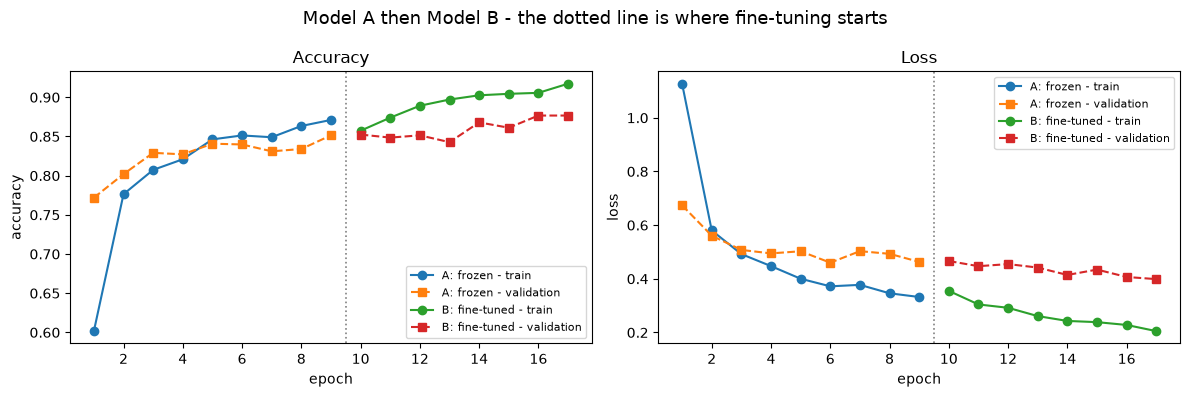

In [22]:
plot_history(
    [("A: frozen", history_head), ("B: fine-tuned", history_finetune)],
    "Model A then Model B - the dotted line is where fine-tuning starts",
)

## 8. Evaluation On The Test Data

The test slice was put aside in section 6 and has not been used for training or for any decision I made,
so this is a clean held out score. I evaluate both models here, A with the frozen backbone and B with the
fine-tuned tail, so I can show that fine-tuning was worth the extra minutes instead of assuming it.

In [23]:
y_true=np.concatenate([labels.numpy() for _, labels in test_ds])

probs_b=model.predict(test_ds, verbose=0)
y_pred_b=probs_b.argmax(axis=1)

model_a=keras.models.load_model(os.path.join(artifacts,"model_a_feature_extraction.keras"))
probs_a=model_a.predict(test_ds, verbose=0)
y_pred_a=probs_a.argmax(axis=1)

print(f"test images: {len(y_true)}")

test images: 1030


Accuracy on its own says very little on an imbalanced eleven class problem, so I also report:
- **balanced accuracy**, the average recall over the eleven classes, so the small classes count as much as
  `rime` does
- **macro F1**, which treats every class as equally important
- **weighted F1**, which weights by class size

The gap between macro F1 and weighted F1 is the interesting part here: if the weighted number is clearly
higher, the model is doing well on the big classes and worse on the small ones.

In [24]:
def score(y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }

results=pd.DataFrame({
    "Model A (frozen)": score(y_pred_a),
    "Model B (fine-tuned)": score(y_pred_b),
}).T.round(4)

display(results)

,accuracy,balanced_accuracy,macro_f1,weighted_f1
Model A (frozen),0.8447,0.8553,0.8547,0.8442
Model B (fine-tuned),0.8718,0.8844,0.8790,0.8723


In [25]:
best_name=results["macro_f1"].idxmax()
is_b=best_name.startswith("Model B")

final_model=model if is_b else model_a
y_pred=y_pred_b if is_b else y_pred_a
probs=probs_b if is_b else probs_a

print(f"the model I keep: {best_name}")

the model I keep: Model B (fine-tuned)


Fine-tuning is the better model on every metric: accuracy goes from 0.845 to 0.872 and macro F1 from
0.855 to 0.879, for about ten extra minutes of training. That is the point of unfreezing the tail, ice
and haze textures are not ImageNet categories, so the frozen features were never going to separate frost
from rime on their own.

One thing worth noting in both models is that macro F1 and weighted F1 land within half a point of each
other, and balanced accuracy is slightly *above* plain accuracy. The class weights did their job, the
model is not buying accuracy by favouring `rime`, its weak classes are not the small ones.

### 8.1 Per Class Performance

In [26]:
report=classification_report(y_true, y_pred, target_names=class_names, digits=3, output_dict=True)

display(pd.DataFrame(report).T.round(3))

,precision,recall,f1-score,support
dew,0.892,0.943,0.917,105.000
fogsmog,0.936,0.805,0.866,128.000
frost,0.674,0.873,0.761,71.000
glaze,0.843,0.729,0.782,96.000
hail,0.963,0.888,0.924,89.000
lightning,0.948,0.982,0.965,56.000
rain,0.826,0.962,0.889,79.000
rainbow,1.000,0.943,0.971,35.000
rime,0.902,0.851,0.876,174.000
sandstorm,0.839,0.904,0.870,104.000


The per class table is where the model stops looking uniform:

- **rainbow (0.971 F1), lightning (0.965), hail (0.924) and dew (0.917)** are the strong ones. Rainbow has
  perfect precision, when the model says rainbow it is never wrong, which fits, a colour arc looks like
  nothing else here. That is also the reassuring part, rainbow is the smallest class with only 35 test
  photos and it still ends up near the top, so the imbalance did not sink it.
- **glaze (0.782 F1) and frost (0.761)** are the weak ones, and they fail in opposite ways. Glaze has the
  lowest recall (0.729), it gets missed. Frost has the lowest precision (0.674), it gets over predicted.
  Put together that is one behaviour and not two: when the model sees ice on a surface it leans to frost.
- **fogsmog** has high precision (0.936) but low recall (0.805), so a fifth of the fog photos are being
  called something else.

### 8.2 Confusion Matrix

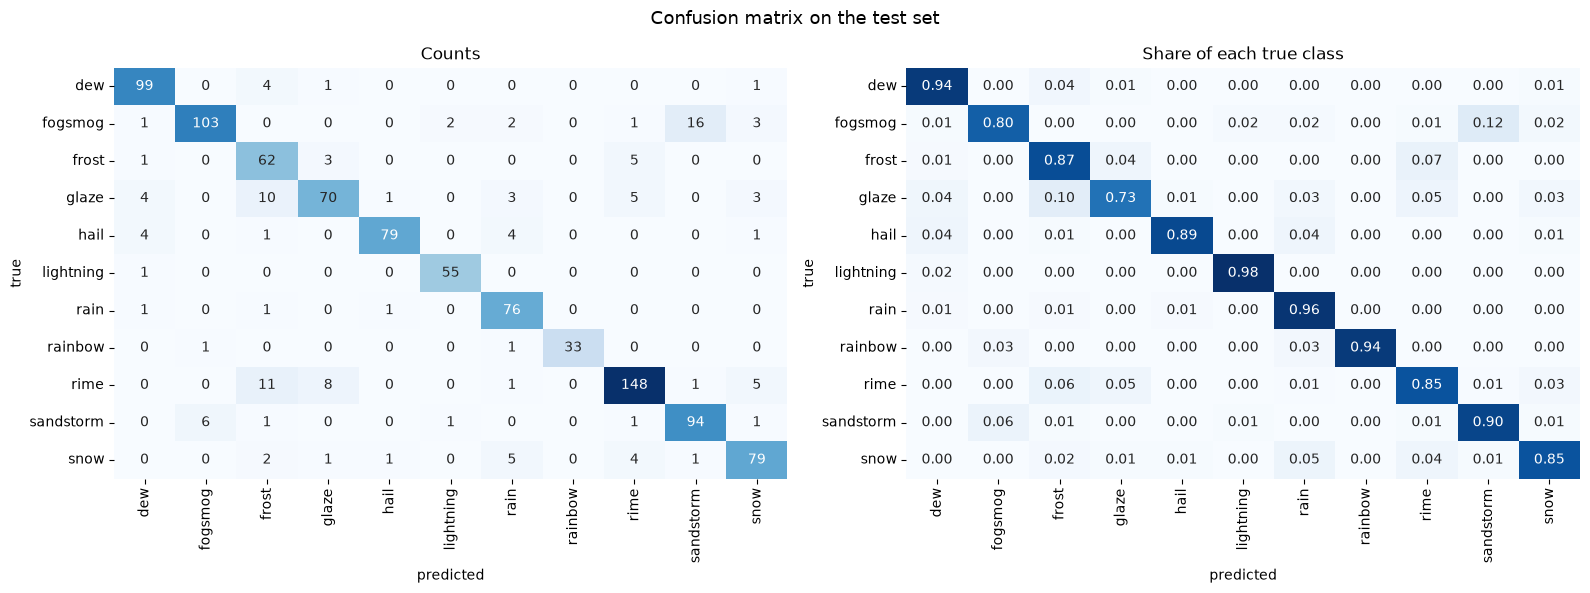

In [27]:
cm=confusion_matrix(y_true, y_pred)
cm_norm=cm/cm.sum(axis=1, keepdims=True)

fig, axes=plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set(title="Counts", xlabel="predicted", ylabel="true")

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", cbar=False,
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set(title="Share of each true class", xlabel="predicted", ylabel="true")

fig.suptitle("Confusion matrix on the test set", fontsize=13)
fig.tight_layout()
plt.show()

In [28]:
pairs=[]
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i!=j and cm[i, j]>0:
            pairs.append({
                "true": class_names[i],
                "predicted": class_names[j],
                "count": int(cm[i, j]),
                "share_of_true_class": round(cm[i, j]/cm[i].sum(), 3),
            })

confused=pd.DataFrame(pairs).sort_values("count", ascending=False).head(10).reset_index(drop=True)
display(confused)

,true,predicted,count,share_of_true_class
0,fogsmog,sandstorm,16,0.125
1,rime,frost,11,0.063
2,glaze,frost,10,0.104
3,rime,glaze,8,0.046
4,sandstorm,fogsmog,6,0.058
5,snow,rain,5,0.054
6,glaze,rime,5,0.052
7,rime,snow,5,0.029
8,frost,rime,5,0.070
9,hail,dew,4,0.045


The mistakes are concentrated, not spread out, and they sit exactly where I guessed they would when I
was looking at the sample images in the EDA:

- **the ice cluster, frost / glaze / rime**, is the whole story. 11 rime photos called frost, 10 glaze
  called frost, 8 rime called glaze, 5 glaze called rime, 5 frost called rime. Between them the ice
  classes trade around 40 photos, roughly a third of every mistake the model makes. That is physically
  reasonable, all three are ice on a surface and what separates them is a fine texture, a crystal
  pattern against a clear glazed layer against a frozen fog crust, which is the first thing to soften
  when a photo is resized to 224x224.
- **fogsmog and sandstorm**, 16 photos one way and 6 back. Both are a low contrast haze that washes out
  the whole frame, and the real difference is the colour of the air, grey against orange, which is a
  thinner signal than it sounds once a photo is overexposed or shot at sunset.
- **snow and rain**, a handful each way, the wet grey street problem, a slushy road belongs to either
  class depending on the day.

Everything else is single digits.

### 8.3 The Mistakes It Was Most Sure About

132 wrong out of 1030


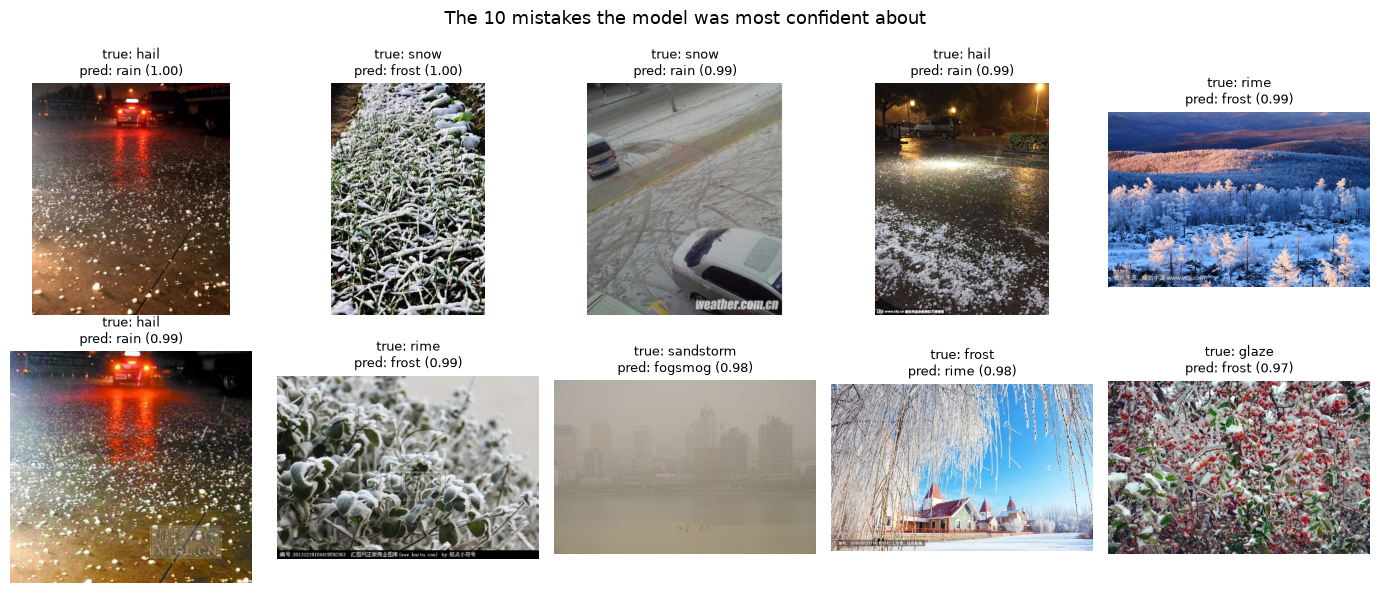

In [29]:
test_index=test_df.reset_index(drop=True).copy()

# make_ds keeps the dataframe order and the test set is not shuffled, this line makes sure of it
assert (test_index["class_name"].map(class_names.index).values==y_true).all()

test_index["predicted"]=[class_names[k] for k in y_pred]
test_index["confidence"]=probs.max(axis=1)

mistakes=test_index[test_index["class_name"]!=test_index["predicted"]].sort_values("confidence", ascending=False)
print(f"{len(mistakes)} wrong out of {len(test_index)}")

fig, axes=plt.subplots(2, 5, figsize=(14, 6))
for ax, (_, row_data) in zip(axes.ravel(), mistakes.head(10).iterrows()):
    ax.imshow(Image.open(row_data["image_path"]))
    ax.set_title(f"true: {row_data['class_name']}\npred: {row_data['predicted']} ({row_data['confidence']:.2f})", fontsize=9)
    ax.axis("off")

fig.suptitle("The 10 mistakes the model was most confident about", fontsize=13)
fig.tight_layout()
plt.show()

These are worth looking at closely, because they change how I read the error rate. Several of them are
photos I would not have labelled confidently myself, ice on a branch that could be called rime or glaze
with equal justification, and haze that could be dust or fog. The model is not making random mistakes
here, it is making the mistake a person would make on a genuinely ambiguous photo, and it is making it
with high confidence, which is the part that matters, a confident wrong answer is the one that gets
through unchecked.

It is also an argument for not chasing the last few points on these classes with more training. Part of
this boundary is in the labels themselves rather than in the model.

### 8.4 What This Means For The Review Team

The business ask was not only accuracy, it was that a person should only step in on the genuinely ambiguous
shots. So the useful question is: if the camera feed is only auto tagged when the model is confident, how
much of the feed does that clear and how good is the tagging on that part?

In [30]:
confidence=probs.max(axis=1)
correct=(y_pred==y_true)

rows=[]
for threshold in [0.0, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]:
    auto=confidence>=threshold
    rows.append({
        "confidence_threshold": threshold,
        "auto_tagged_share": auto.mean(),
        "accuracy_on_auto_tagged": correct[auto].mean(),
        "photos_sent_to_review": int((~auto).sum()),
    })

display(pd.DataFrame(rows).round(3))

,confidence_threshold,auto_tagged_share,accuracy_on_auto_tagged,photos_sent_to_review
0,0.00,1.000,0.872,0
1,0.50,0.949,0.895,53
2,0.60,0.894,0.919,109
3,0.70,0.845,0.929,160
4,0.80,0.781,0.944,226
5,0.90,0.695,0.962,314
6,0.95,0.625,0.975,386


This table is the real answer to the business question. At a threshold of **0.70** the model tags
**84.5%** of the photos on its own and is **92.9%** accurate on that part, sending 160 photos out of 1030
to a person. Push it to **0.90** and the auto tagged part is **96.2%** accurate while still clearing
69.5% of the feed.

So the review team goes from opening every photo from every camera to opening about one in six, and the
ones they do open are the ambiguous ice and haze shots, which is where a human is actually useful. Which
threshold to ship is a product decision rather than a modelling one, it depends on how expensive a wrong
tag is compared to a reviewer's minute, so I leave the whole table instead of picking one number.

## 9. Saving What The Streamlit App Needs

The app should not know anything about training. I save one model file and one small json with the class
order and the input size, and that is the whole contract between this notebook and `app.py`. The
preprocessing lives inside the model itself, so the app only has to resize an uploaded photo and hand it over.

In [31]:
final_model.save(os.path.join(artifacts,"weather_model.keras"))

with open(os.path.join(artifacts,"class_names.json"),"w") as f:
    json.dump({"class_names": class_names, "img_size": list(img_size)}, f, indent=2)

print("artifacts folder:", os.listdir(artifacts))
print("tensorflow:", tf.__version__, "| keras:", keras.__version__)

artifacts folder: ['class_names.json', 'model_a_feature_extraction.keras', 'model_b_finetuned.keras', 'weather_model.keras']
tensorflow: 2.21.0 | keras: 3.15.1


In [32]:
# same path an uploaded photo will take inside the app, just to be sure it works outside a tf.data pipeline
sample=test_index.iloc[0]

img=Image.open(sample["image_path"]).convert("RGB").resize(img_size)
batch=np.expand_dims(np.array(img, dtype="float32"), axis=0)
p=final_model.predict(batch, verbose=0)[0]

print(f"true: {sample['class_name']}")
print(f"predicted: {class_names[int(p.argmax())]} with confidence {p.max():.2f}")

true: dew
predicted: dew with confidence 1.00


## 10. Write Up

**What I built.** An eleven class weather condition classifier on the Weather Image Recognition dataset
(6862 photos), built as transfer learning on MobileNetV2 in Keras and trained in two stages, first the
classifier head with the backbone frozen, then the last block of the backbone fine-tuned at a 100x
smaller learning rate. On the 1030 photo held out test set it reaches **87.2% accuracy**, **0.884
balanced accuracy** and **0.879 macro F1**. The final model is saved as a single file and served through
a Streamlit app that takes an uploaded photo and returns the condition with its confidence.

**What worked.** Transfer learning was clearly the right call, the frozen backbone was already at 77%
validation accuracy after a single epoch, which a network trained from scratch on 4800 photos would not
come near. Fine-tuning the tail was worth the extra ten minutes, it moved macro F1 from 0.855 to 0.879
and helped where I wanted it to, on the ice classes, because those textures are not something an
ImageNet backbone already knows. Class weighting worked too, rainbow is the smallest class at 232 photos
and ended up with the second best F1 in the table, and balanced accuracy came out slightly above plain
accuracy, which is the sign that no class was quietly sacrificed to the big ones.

**What did not work as well.** Model A plateaued early, early stopping restored epoch 6 of 9 and the
learning rate had already been cut once, so more head only training was not going anywhere. Model B is
the opposite problem, it was still improving when it hit my epoch cap, the last epoch was also the best
one (val_loss 0.399), so there is accuracy left on the table there, and that cap was a CPU budget
decision rather than a modelling one. Neither of those fixes the ice cluster, which is where most of the
remaining error lives.

**Which classes get confused and why.** frost, glaze and rime, in every direction, are about a third of
all errors. Frost is over predicted (precision 0.674) and glaze is under predicted (recall 0.729), which
is the same problem from two sides, when the model sees ice it leans to frost. All three are close ups of
ice and the thing that separates them is a fine texture that partly disappears in the resize to 224x224.
Second is fogsmog against sandstorm, 22 photos between them, both a low contrast haze where the real
difference is the colour of the air. snow and rain trade a few for the wet grey street reason. Everything
with its own colour signature, rainbow, lightning, hail and dew, sits comfortably above 0.9 F1.

**Which approach I recommend.** Model B, the fine-tuned one. It is better on every metric, it costs about
ten extra minutes to train and the saved file is in the same size class, so there is no reason to ship
Model A. I would put it behind the confidence threshold from section 8.4 rather than run it on its own,
at 0.70 it handles 84.5% of the feed at 92.9% accuracy, which describes the product far better than the
raw 87.2% does.

**What I would try next with more time.**
- Let Model B run longer, it had not converged, and unfreeze one more block now that I know the tail
  helps instead of overfitting.
- A bigger backbone, EfficientNetB0 or ConvNeXt-Tiny, since the failure mode is fine texture and those
  keep more of it than MobileNetV2 does.
- Train at a higher resolution, 320 or 384, aimed specifically at the ice classes, because the evidence
  the model needs is exactly what the downscale is throwing away.
- Go through the frost, glaze and rime folders by hand. Some of that boundary looks like label noise, and
  if it is, cleaning those labels is worth more than anything above.
- Treat the ice cluster as two steps, one model that decides the photo is ice, then a small model trained
  only on frost, glaze and rime to say which one.